# **Astronomy: Pulsar Candidates Classification Using Radio Emission Data**

# **Importing Relevent Libraries and Loading Dataset**

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
column_names = [
    'Profile_mean', 'Profile_stdev', 'Profile_skewness', 'Profile_kurtosis',
    'DM_mean', 'DM_stdev', 'DM_skewness', 'DM_kurtosis', 'class'
]
df = pd.read_csv('HTRU_2.csv', names=column_names)



## **Data Inspection**

In [6]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Profile_mean      17898 non-null  float64
 1   Profile_stdev     17898 non-null  float64
 2   Profile_skewness  17898 non-null  float64
 3   Profile_kurtosis  17898 non-null  float64
 4   DM_mean           17898 non-null  float64
 5   DM_stdev          17898 non-null  float64
 6   DM_skewness       17898 non-null  float64
 7   DM_kurtosis       17898 non-null  float64
 8   class             17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis,class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


# **Exploratory Data Analysis**

## **Checking Missing Values**

In [7]:
def check_data_quality(df):
    """
    Checks for missing values and duplicate rows in the dataset.
    """
    # 1. Missing Values Calculation
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    missing_table = pd.concat([missing_count, missing_percent], axis=1, keys=['Missing Count', 'Percentage (%)'])

    print("--- Missing Values Summary ---")
    print(missing_table)

    # 2. Duplicate Rows Calculation
    duplicate_count = df.duplicated().sum()
    print(f"\n--- Duplicates Summary ---")
    print(f"Total duplicate rows identified: {duplicate_count}")

# Execute the check
check_data_quality(df)

--- Missing Values Summary ---
                  Missing Count  Percentage (%)
Profile_mean                  0             0.0
Profile_stdev                 0             0.0
Profile_skewness              0             0.0
Profile_kurtosis              0             0.0
DM_mean                       0             0.0
DM_stdev                      0             0.0
DM_skewness                   0             0.0
DM_kurtosis                   0             0.0
class                         0             0.0

--- Duplicates Summary ---
Total duplicate rows identified: 0


## **Class Distribution Analysis**

C:\Users\adapa\AppData\Local\Temp\ipykernel_13948\3156304015.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='viridis')


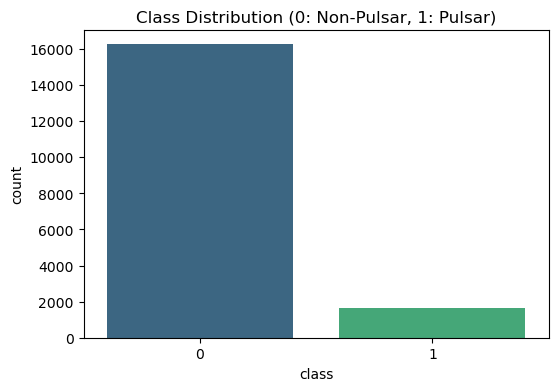

Class Counts:
 class
0    16259
1     1639
Name: count, dtype: int64

Percentage Distribution:
 class
0    90.842552
1     9.157448
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df, palette='viridis')
plt.title('Class Distribution (0: Non-Pulsar, 1: Pulsar)')
plt.show()

print("Class Counts:\n", df['class'].value_counts())
print("\nPercentage Distribution:\n", df['class'].value_counts(normalize=True) * 100)

## **Correlation Heatmap**

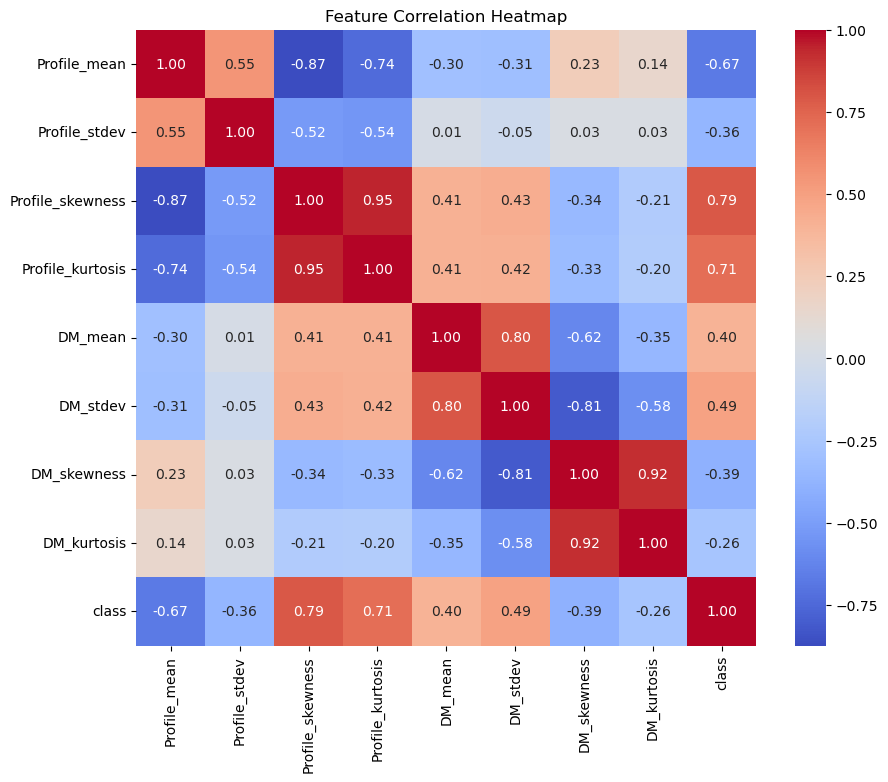

In [9]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

## **Feature Distribution by Class (KDE Plots)**

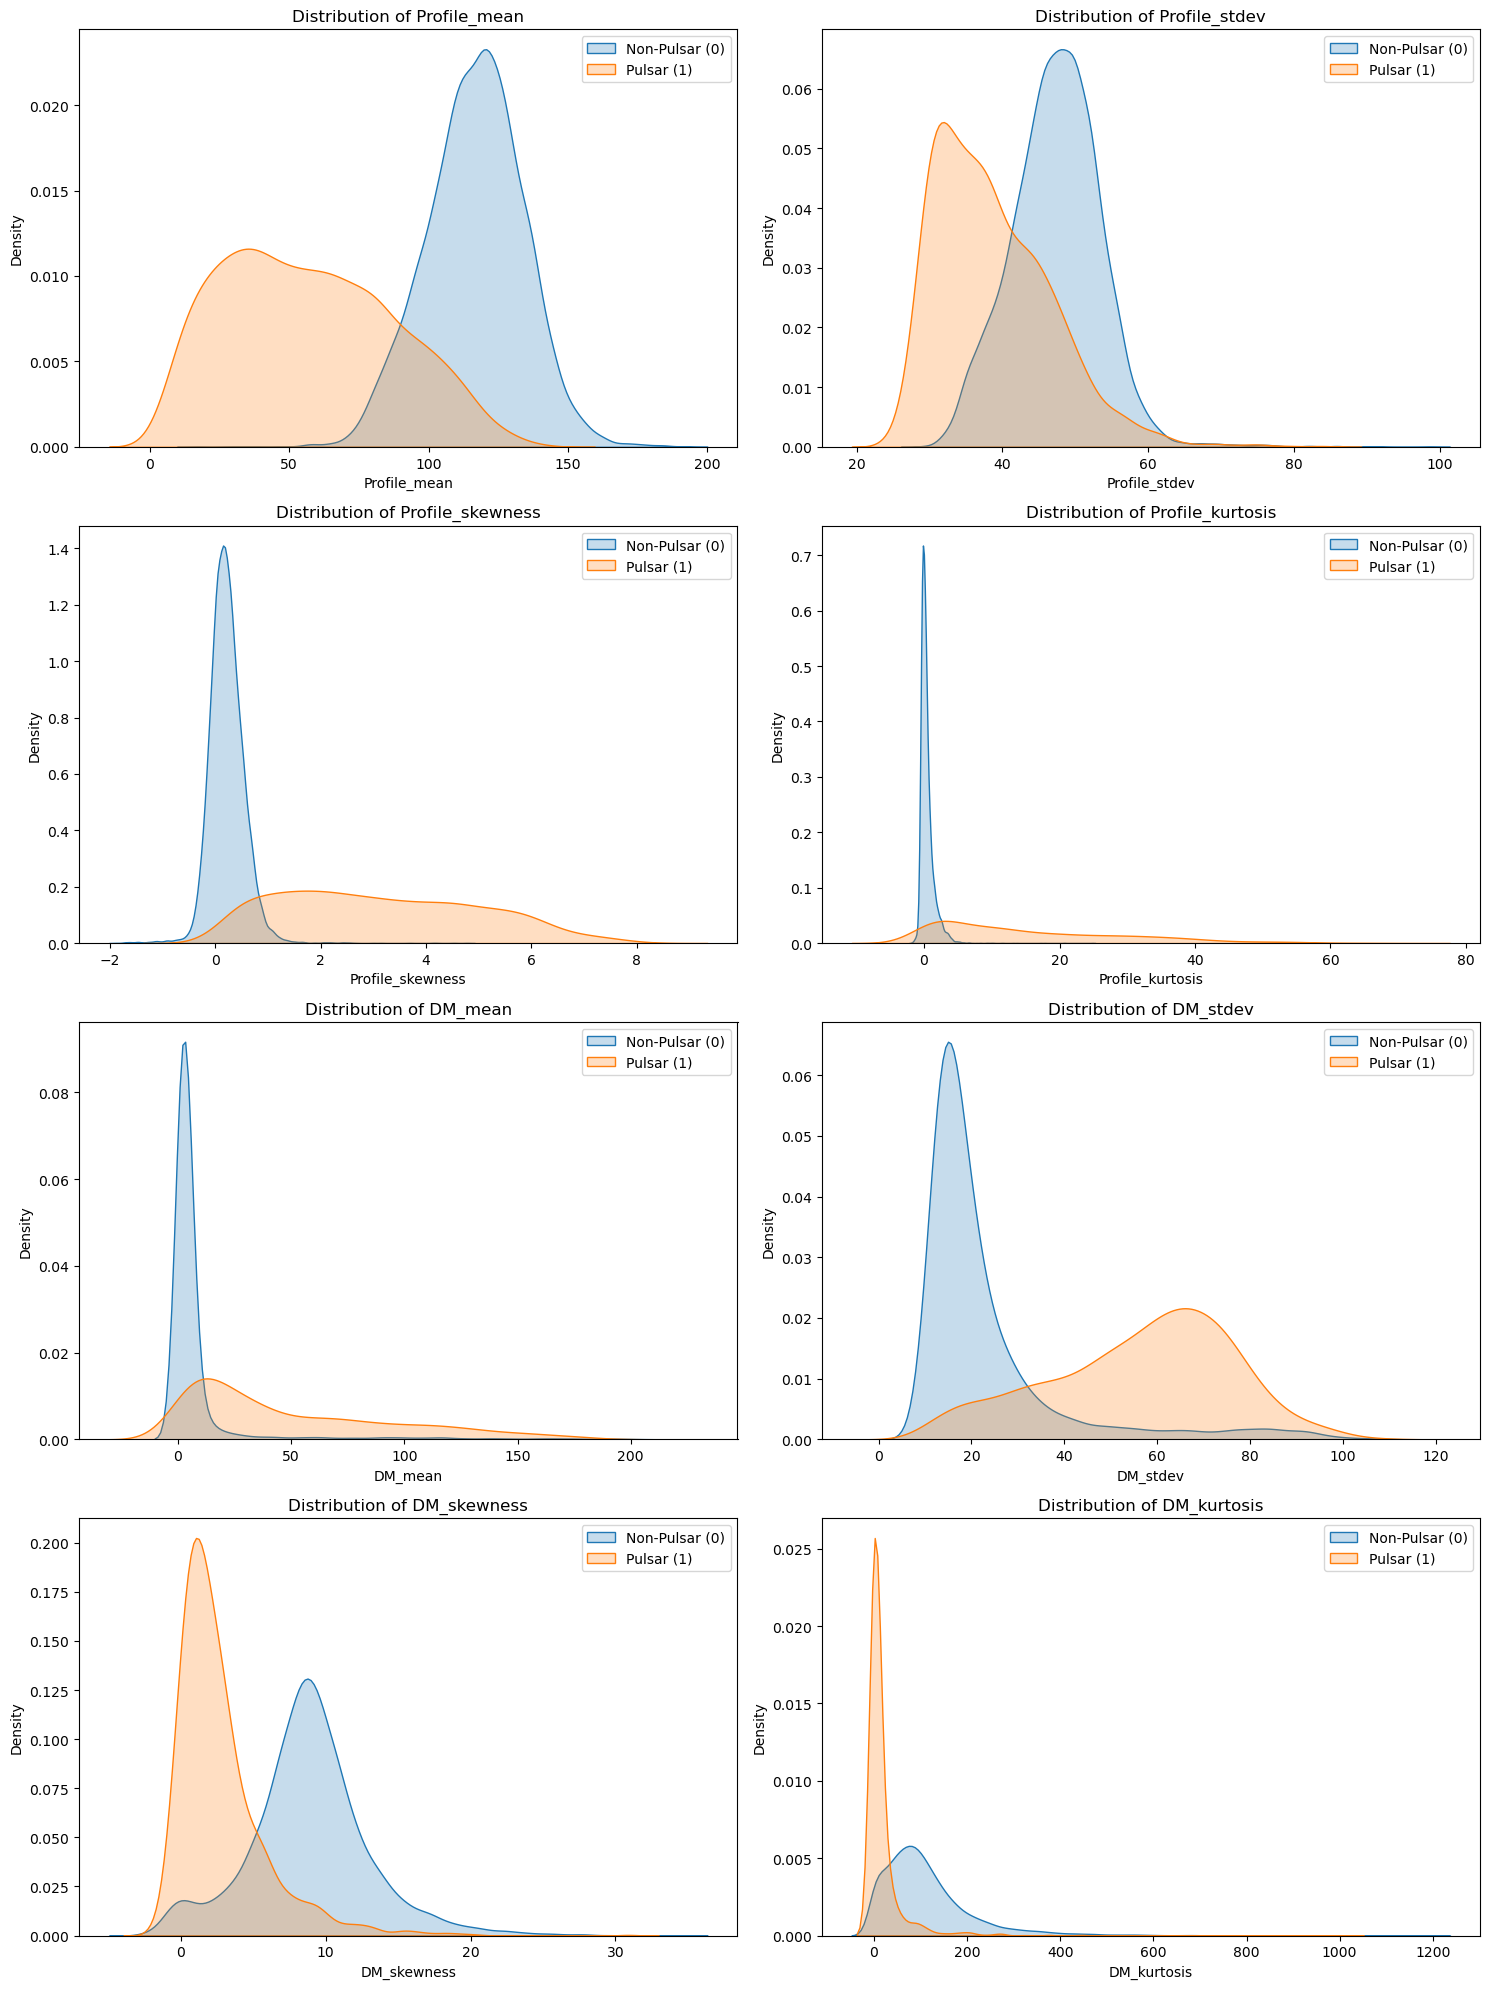

In [10]:
features = df.columns[:-1]
plt.figure(figsize=(15, 20))
for i, col in enumerate(features):
    plt.subplot(4, 2, i + 1)
    sns.kdeplot(df[df['class'] == 0][col], label='Non-Pulsar (0)', fill=True)
    sns.kdeplot(df[df['class'] == 1][col], label='Pulsar (1)', fill=True)
    plt.title(f'Distribution of {col}')
    plt.legend()
plt.tight_layout()
plt.show()

## **Boxplots for Outlier Detection**

C:\Users\adapa\AppData\Local\Temp\ipykernel_13948\60237468.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=col, data=df, palette='Set2')
C:\Users\adapa\AppData\Local\Temp\ipykernel_13948\60237468.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=col, data=df, palette='Set2')
C:\Users\adapa\AppData\Local\Temp\ipykernel_13948\60237468.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=col, data=df, palette='Set2')
C:\Users\adapa\AppData\Local\Temp\ipykernel_13948\60237468.py:4: FutureWarning: 

Pas

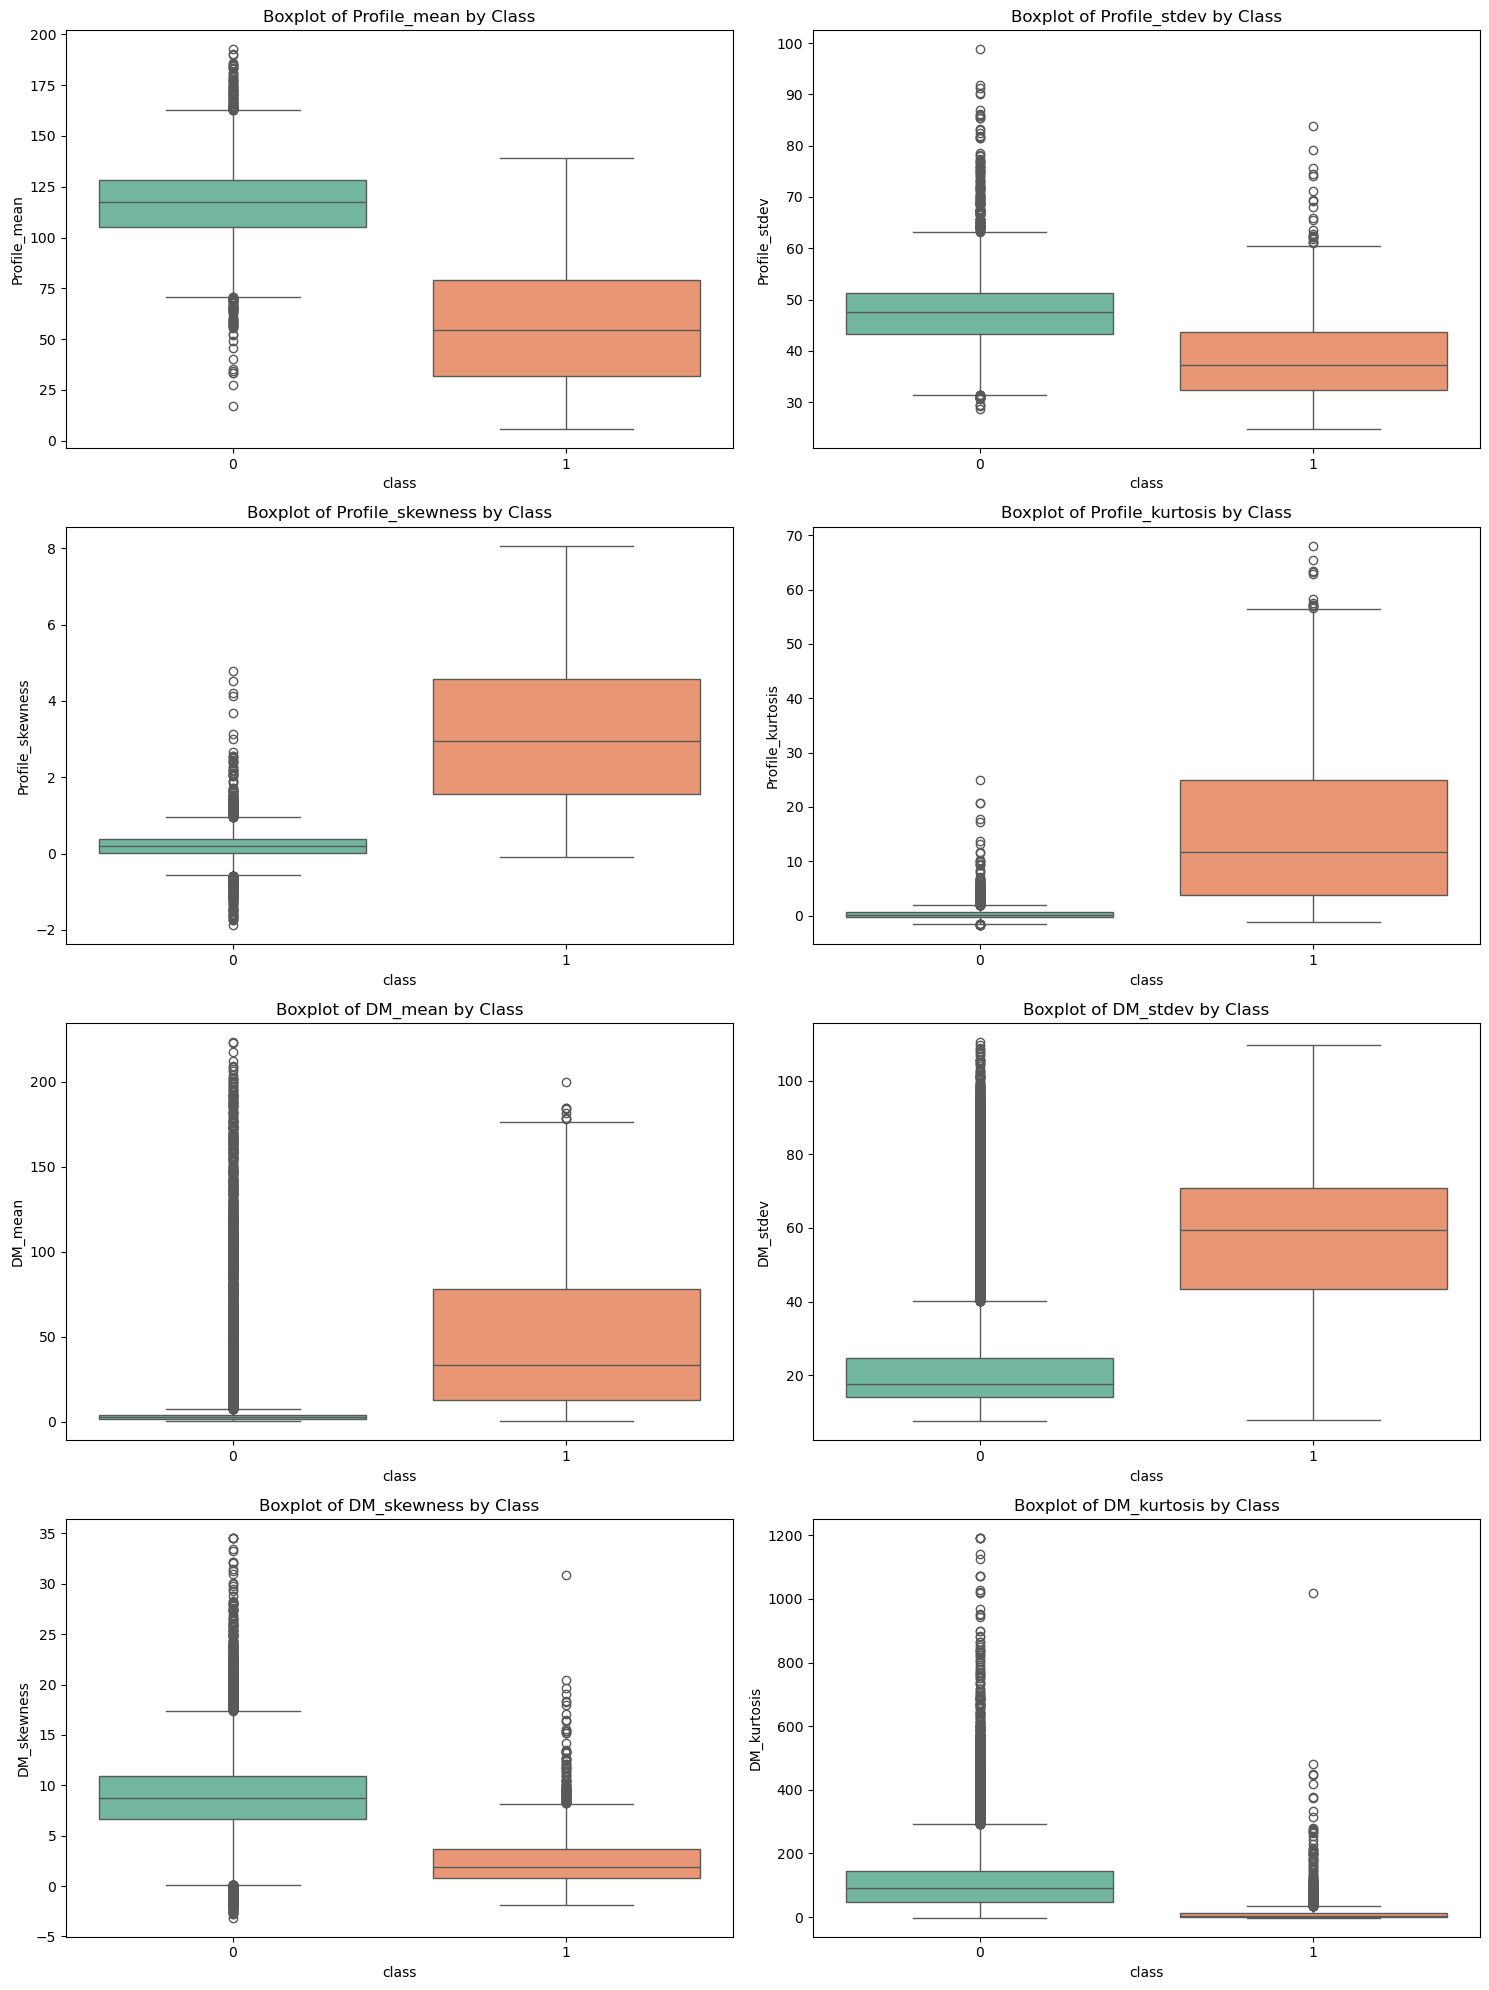

In [11]:
plt.figure(figsize=(15, 20))
for i, col in enumerate(features):
    plt.subplot(4, 2, i + 1)
    sns.boxplot(x='class', y=col, data=df, palette='Set2')
    plt.title(f'Boxplot of {col} by Class')
plt.tight_layout()
plt.show()

## **Multivariate Analysis (Pairplot)**

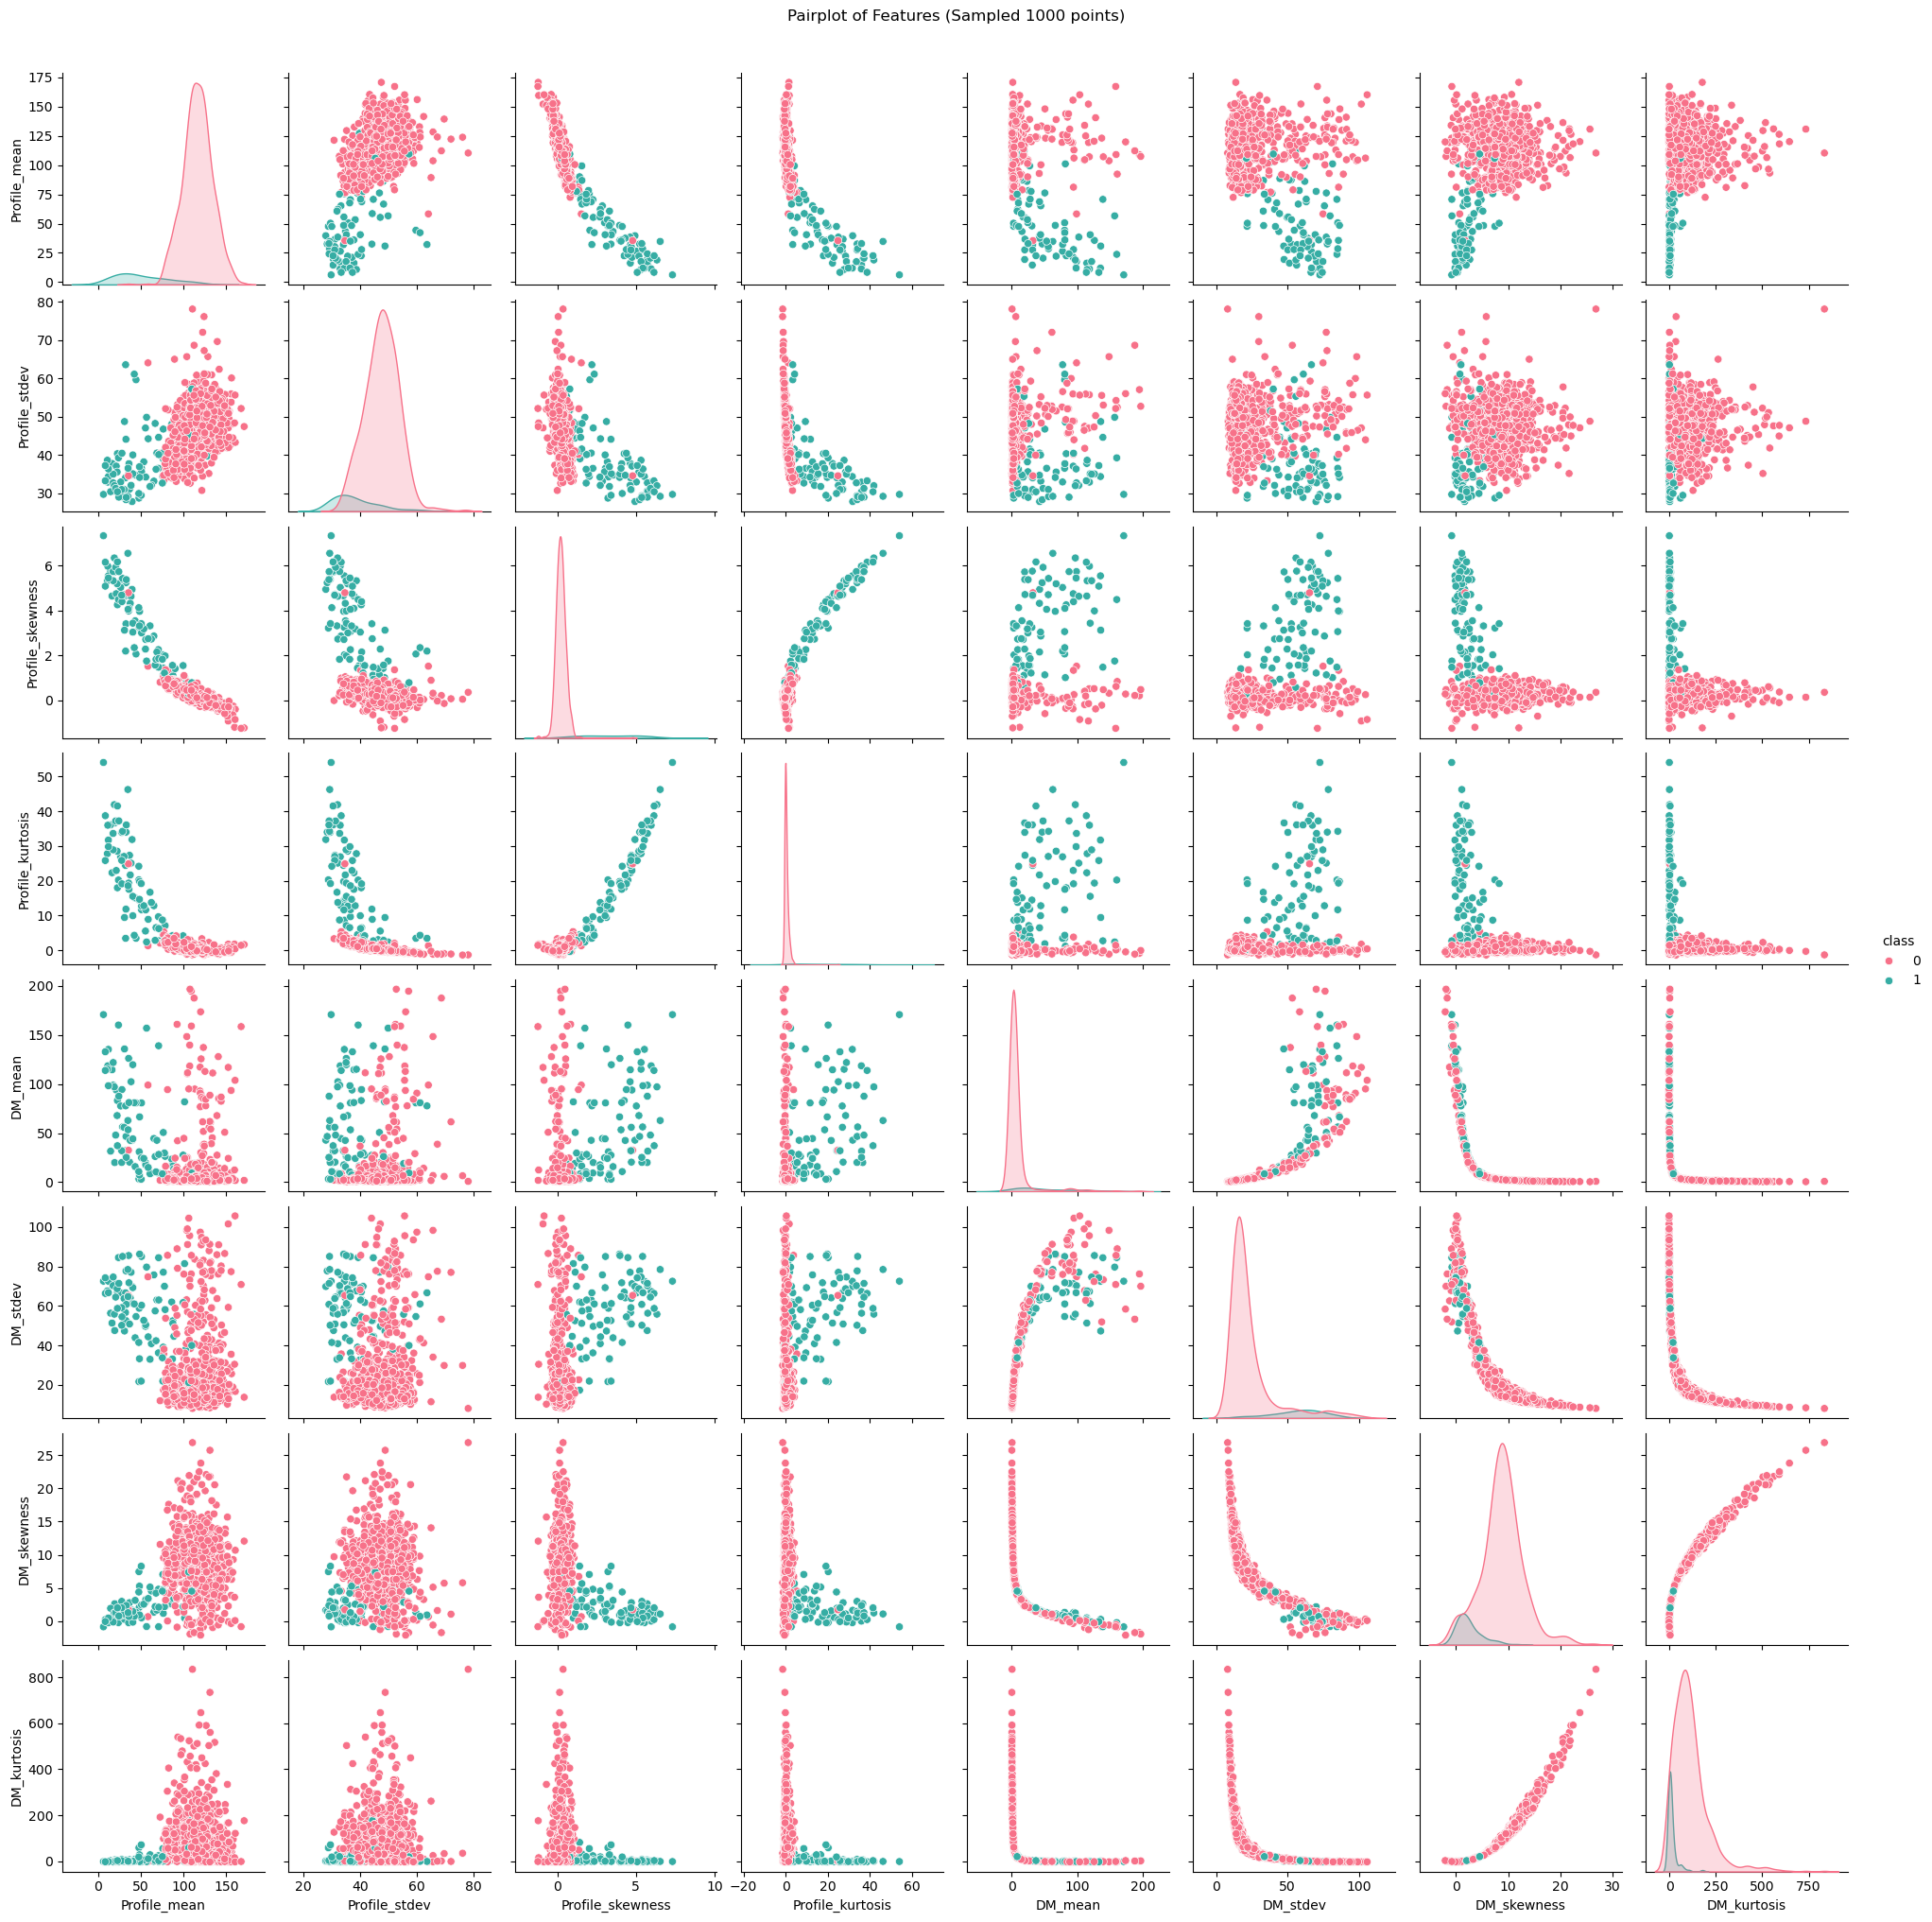

In [12]:
# Sampling for efficiency
sample_df = df.sample(1000, random_state=42)
sns.pairplot(sample_df, hue='class', palette='husl', diag_kind='kde')
plt.suptitle('Pairplot of Features (Sampled 1000 points)', y=1.02)
plt.show()

In [13]:
df.head()

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis,class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


# **Model Training**

## **Preprocessing**

In [14]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

# Assuming df is your dataframe
X = df.drop('class', axis=1)
y = df['class']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete. Data scaled and split.")

Preprocessing complete. Data scaled and split.


## **Model Training & EValuation**

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True)
}

results = {}

for name, model in models.items():
    # Training with time tracking
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_train

    # Prediction with time tracking
    start_test = time.time()
    y_pred = model.predict(X_test_scaled)
    test_time = time.time() - start_test

    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics calculation
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Train Time": train_time,
        "Test Time": test_time,
        "cm": confusion_matrix(y_test, y_pred),
        "fpr": roc_curve(y_test, y_prob)[0],
        "tpr": roc_curve(y_test, y_prob)[1]
    }

# Display Results Table
results_df = pd.DataFrame(results).T.drop(['cm', 'fpr', 'tpr'], axis=1)
print(results_df)

                     Accuracy Precision    Recall        F1       AUC  \
Logistic Regression  0.979609  0.944251   0.82622  0.881301  0.970987   
Random Forest        0.981006  0.924837  0.862805  0.892744  0.968045   
SVM                  0.980726  0.948097  0.835366  0.888169  0.954186   

                    Train Time Test Time  
Logistic Regression   0.024674  0.000294  
Random Forest         2.471139  0.026391  
SVM                   3.298759   0.24504  


## **Visualization**

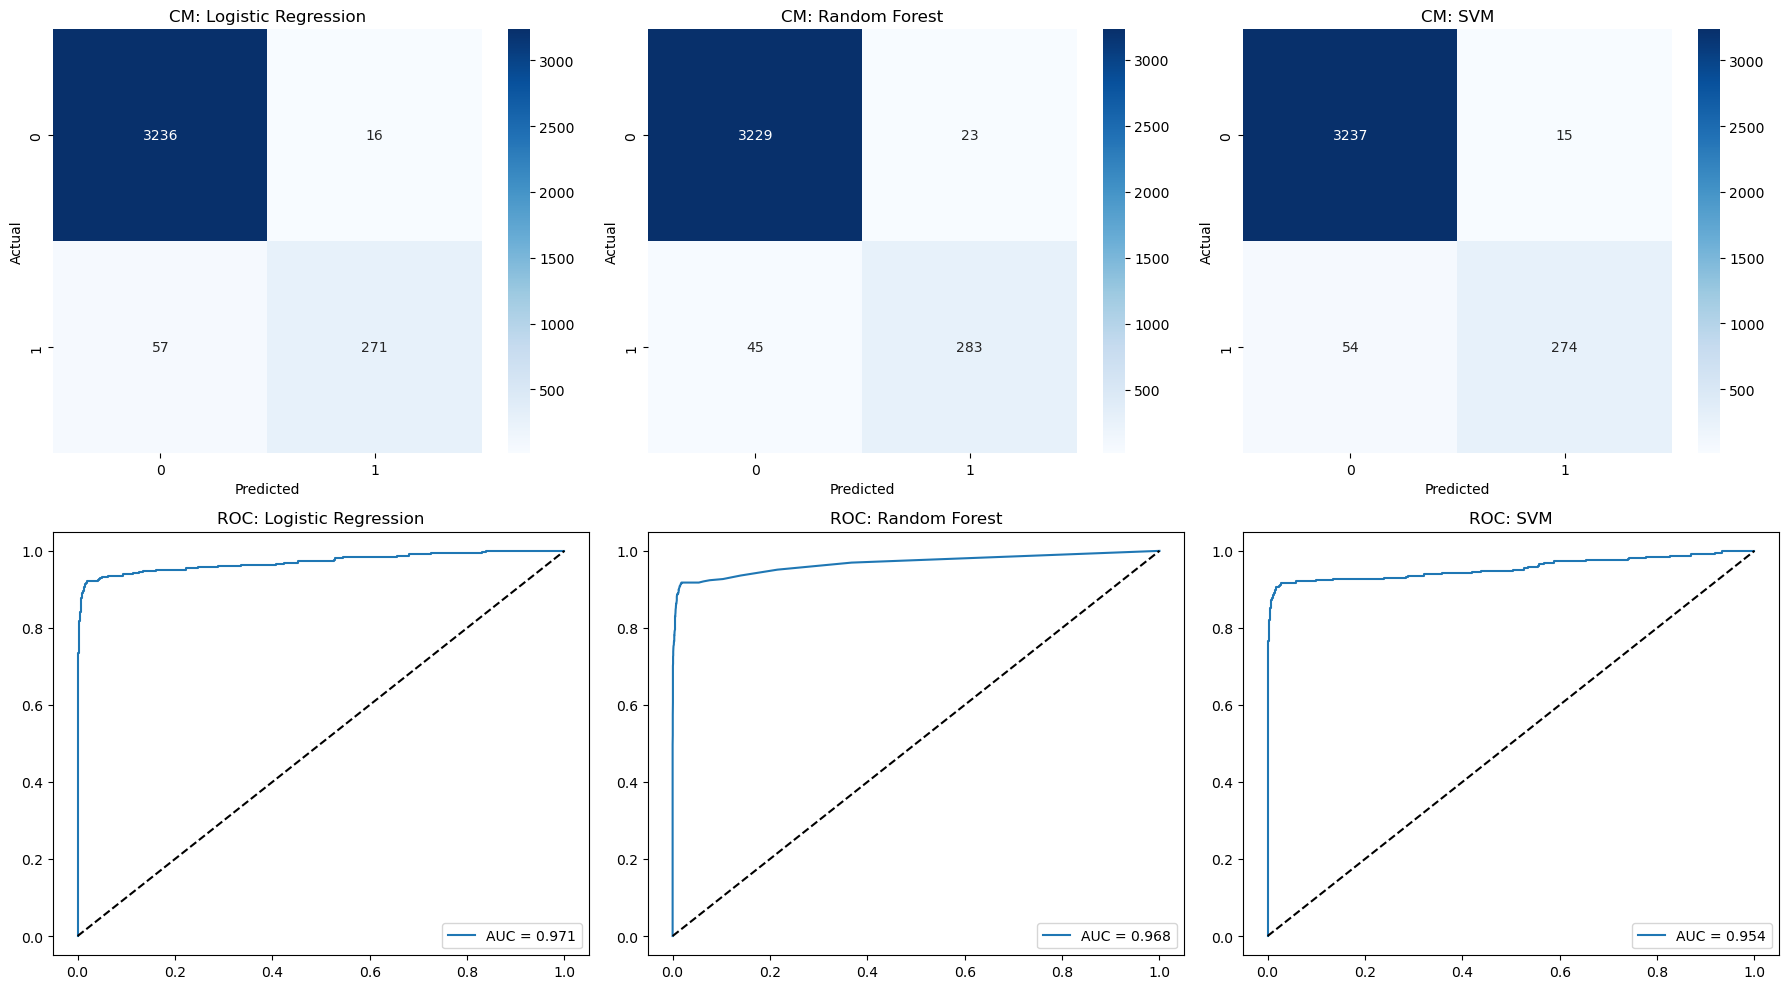

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (name, data) in enumerate(results.items()):
    # Plot Confusion Matrix
    sns.heatmap(data['cm'], annot=True, fmt='d', ax=axes[0, i], cmap='Blues')
    axes[0, i].set_title(f"CM: {name}")
    axes[0, i].set_xlabel("Predicted")
    axes[0, i].set_ylabel("Actual")

    # Plot ROC Curve
    axes[1, i].plot(data['fpr'], data['tpr'], label=f"AUC = {data['AUC']:.3f}")
    axes[1, i].plot([0, 1], [0, 1], 'k--')
    axes[1, i].set_title(f"ROC: {name}")
    axes[1, i].legend(loc='lower right')

plt.tight_layout()
plt.show()

# **Hyperparameter tuning using Grid Search**

In [17]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grids
param_grids = {
    "Logistic Regression": {
        'C': [0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear']
    },
    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf']
    }
}

tuned_results = {}

for name, model in models.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=3,
        scoring='f1', # Optimized for F1 due to potential class imbalance
        n_jobs=-1
    )

    grid_search.fit(X_train_scaled, y_train)
    best_model = grid_search.best_estimator_

    # Predict with best parameters
    y_pred = best_model.predict(X_test_scaled)

    # Store results
    tuned_results[name] = {
        "Best Params": grid_search.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    }

# Display Tuned Results
tuned_df = pd.DataFrame(tuned_results).T
print(tuned_df[['Accuracy', 'F1', 'Precision', 'Recall']])

Tuning Logistic Regression...
Tuning Random Forest...
Tuning SVM...
                     Accuracy        F1 Precision    Recall
Logistic Regression  0.979888  0.882736  0.947552   0.82622
Random Forest        0.980726   0.89065  0.927393  0.856707
SVM                  0.981006  0.891374  0.936242   0.85061


## **K-Fold Cross Validation**

In [18]:
from sklearn.model_selection import cross_validate
import numpy as np

# Define the metrics we want to track
scoring_metrics = ['accuracy', 'f1', 'precision', 'recall']

cv_results_summary = {}

print("Starting 5-Fold Cross-Validation...")

for name, model in models.items():
    # Perform cross-validation
    cv_scores = cross_validate(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring=scoring_metrics
    )

    # Calculate mean and standard deviation for each metric
    cv_results_summary[name] = {
        "Avg Accuracy": np.mean(cv_scores['test_accuracy']),
        "Avg F1": np.mean(cv_scores['test_f1']),
        "Avg Precision": np.mean(cv_scores['test_precision']),
        "Avg Recall": np.mean(cv_scores['test_recall']),
        "F1 Std Dev": np.std(cv_scores['test_f1'])
    }

# Convert to DataFrame for a clean look
cv_df = pd.DataFrame(cv_results_summary).T
print(cv_df)

Starting 5-Fold Cross-Validation...
                     Avg Accuracy    Avg F1  Avg Precision  Avg Recall  \
Logistic Regression      0.978349  0.873460       0.938816    0.816916   
Random Forest            0.979396  0.881962       0.925532    0.842835   
SVM                      0.978698  0.875906       0.938312    0.821490   

                     F1 Std Dev  
Logistic Regression    0.010520  
Random Forest          0.020158  
SVM                    0.009148  
